# Inference Demo

Test the trained model on images or camera feed.

In [2]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.inference.predictor import RecyclingPredictor
from src.inference.camera import CameraInference
from src.utils.config import Config

/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
  data = fetch_version_info()


## 1. Load Predictor

In [ ]:
import serial
import time

class ArduinoController:
    """
    Controla el Arduino Nano enviando instrucciones de clasificación (0-3)
    por comunicación serial USB.
    """
    def __init__(self, port='COM3', baudrate=9600, timeout=2):
        """
        Inicializar conexión con Arduino.
        
        Args:
            port: Puerto serial (ej. 'COM3' en Windows, '/dev/ttyUSB0' en Linux)
            baudrate: Velocidad de comunicación (9600 por defecto en Arduino)
            timeout: Timeout de lectura en segundos
        """
        try:
            self.ser = serial.Serial(port, baudrate, timeout=timeout)
            time.sleep(2)  # Esperar a que Arduino se reinicie tras conectar
            self.ser.reset_input_buffer()
            print(f"✓ Conectado a Arduino en puerto {port} a {baudrate} baud")
            
            # Leer mensaje inicial del Arduino
            if self.ser.in_waiting:
                msg = self.ser.readline().decode('utf-8', errors='ignore').strip()
                print(f"  Arduino: {msg}")
        except serial.SerialException as e:
            print(f"✗ Error conectando a Arduino: {e}")
            print("  Asegúrate de que el Arduino está conectado y el puerto es correcto")
            self.ser = None
    
    def send_instruction(self, class_id):
        """
        Enviar instrucción de clasificación al Arduino.
        
        Args:
            class_id: Identificador de clase (0-3)
                - 0: cardboard_paper
                - 1: ecoglasses
                - 2: metal_plastic
                - 3: trash
        
        Returns:
            bool: True si se envió correctamente, False si hubo error
        """
        if self.ser is None or not self.ser.is_open:
            print("✗ Arduino no conectado")
            return False
        
        if not isinstance(class_id, int) or class_id < 0 or class_id > 3:
            print(f"✗ ID de clase inválido: {class_id}. Debe estar entre 0 y 3")
            return False
        
        try:
            # Enviar como carácter ASCII ('0'-'3')
            self.ser.write(str(class_id).encode('utf-8'))
            print(f"→ Enviado: {class_id}")
            
            # Leer respuesta del Arduino
            response = self.ser.readline().decode('utf-8', errors='ignore').strip()
            if response:
                print(f"  Arduino: {response}")
            
            return True
        except Exception as e:
            print(f"✗ Error enviando instrucción: {e}")
            return False
    
    def close(self):
        """Cerrar conexión con Arduino."""
        if self.ser and self.ser.is_open:
            self.ser.close()
            print("✓ Conexión cerrada")

# Intentar conectar - CAMBIAR EL PUERTO SI ES NECESARIO
# En Windows: 'COM3', 'COM4', etc.
# En Linux: '/dev/ttyUSB0', '/dev/ttyACM0', etc.
# En Mac: '/dev/tty.usbserial-*'
try:
    arduino = ArduinoController(port='COM3', baudrate=9600)
except:
    print("Nota: Ajusta el puerto serial según tu sistema")
    arduino = None

## Arduino Serial Communication Setup

In [ ]:
config = Config('../configs/mobilenet_config.yaml')
model_path = '../outputs/checkpoints/best_model.pt'

class_mapping = {0: 'cardboard_paper', 1: 'ecoglasses', 2: 'metal_plastic', 3: 'trash'}

predictor = RecyclingPredictor(
    model_path=model_path,
    num_classes=config.model.get('num_classes'),
    architecture=config.model.get('architecture'),
    class_mapping=class_mapping
)
print("Predictor loaded.")

Predictor loaded.


/Users/naopersonal/Documents/GitHub/TP-final-vision/src/data/augmentation.py:67: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


## 2. Single Image Prediction

In [4]:
# Test on a sample image from test set
# img_path = '../data/processed/test/some_image.jpg'
# result = predictor.predict(img_path)
# print(result)

## 2.5 Grad-CAM Visualization on Static Images

Visualize which parts of the image the model focuses on for classification.

/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


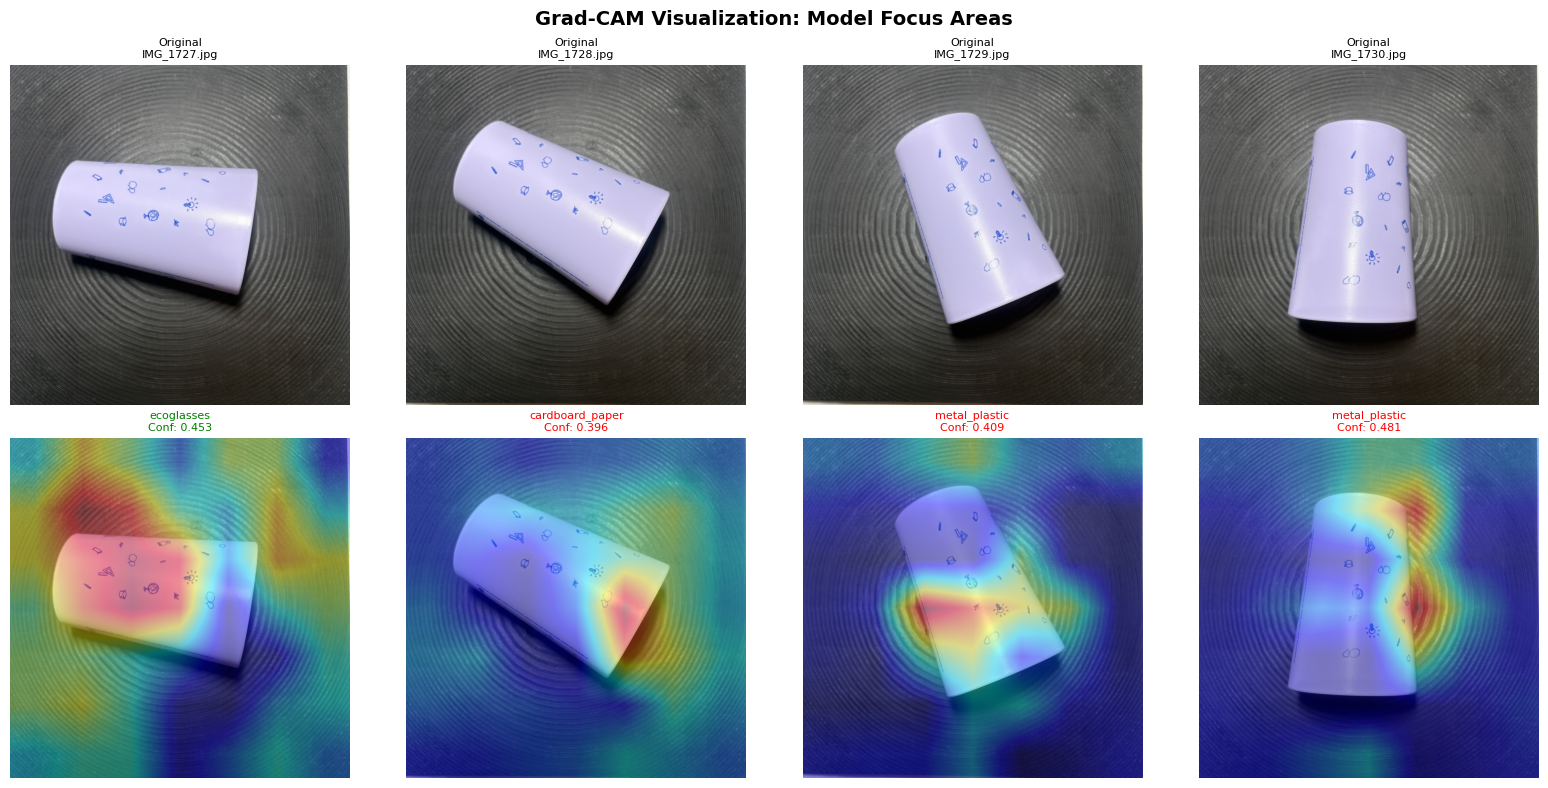


Grad-CAM Interpretation:
- Red/Yellow regions: High importance for classification
- Blue/Purple regions: Low importance
- The heatmap shows which parts of the image influenced the model's decision


In [5]:
from src.inference.gradcam import GradCAMPredictor
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

# Initialize Grad-CAM predictor
gradcam_predictor = GradCAMPredictor(predictor)

# Test on ecoglasses images
ecoglasses_dir = Path('../data/custom/ecoglasses_bandeja_jpg')
test_images = sorted(list(ecoglasses_dir.glob('*.jpg')))[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, img_path in enumerate(test_images):
    # Load image
    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get prediction with Grad-CAM
    result, gradcam_overlay = gradcam_predictor.predict_with_cam(image_rgb)
    
    # Display original
    axes[0, idx].imshow(image_rgb)
    axes[0, idx].set_title(f"Original\n{img_path.name}", fontsize=8)
    axes[0, idx].axis('off')
    
    # Display Grad-CAM overlay
    axes[1, idx].imshow(gradcam_overlay)
    axes[1, idx].set_title(
        f"{result['class_name']}\nConf: {result['confidence']:.3f}", 
        fontsize=8,
        color='green' if result['class_name'] == 'ecoglasses' else 'red'
    )
    axes[1, idx].axis('off')

plt.suptitle('Grad-CAM Visualization: Model Focus Areas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nGrad-CAM Interpretation:")
print("- Red/Yellow regions: High importance for classification")
print("- Blue/Purple regions: Low importance")
print("- The heatmap shows which parts of the image influenced the model's decision")

## 3. Real-time Camera Demo

In [ ]:
# Start camera inference
# Press 'q' to quit window

#para imprimir las probabilidades descomentar línea 110 de predictor.py
camera = CameraInference(predictor, camera_id=0)
camera.run()

## 3. Real-time Camera Demo with Grad-CAM

In [ ]:
from src.inference.camera_gradcam import CameraInferenceWithGradCAM

camera = CameraInferenceWithGradCAM(predictor, camera_id=0, enable_gradcam=True)
camera.run()  # Press 'g' to toggle, 'q' to quit, 's' to save

In [ ]:
from src.inference.camera_gradcam import CameraInferenceWithGradCAM

class CameraInferenceWithArduino(CameraInferenceWithGradCAM):
    """Extiende CameraInferenceWithGradCAM para enviar instrucciones al Arduino."""
    
    def __init__(self, predictor, arduino_controller, camera_id=0, enable_gradcam=True):
        super().__init__(predictor, camera_id=camera_id, enable_gradcam=enable_gradcam)
        self.arduino = arduino_controller
    
    def process_frame(self, frame):
        """Override de process_frame para incluir envío al Arduino."""
        result = super().process_frame(frame)
        
        # Si hay una predicción con buena confianza, enviar al Arduino
        if result and 'class_id' in result:
            # Mapeo de clase a ID 
            if hasattr(result, 'get'):
                confidence = result.get('confidence', 0)
                if confidence > 0.6:  # Umbral de confianza
                    class_id = result.get('class_id', -1)
                    if 0 <= class_id <= 3:
                        self.arduino.send_instruction(class_id)
        
        return result

# Crear instancia de cámara con Arduino integrado
if arduino and arduino.ser:
    camera_arduino = CameraInferenceWithArduino(
        predictor, 
        arduino, 
        camera_id=0, 
        enable_gradcam=True
    )
    camera_arduino.run()  # Press 'g' to toggle Grad-CAM, 'q' to quit, 's' to save
else:
    print("⚠ Arduino no disponible. Ejecutar cámara sin Arduino...")
    camera = CameraInferenceWithGradCAM(predictor, camera_id=0, enable_gradcam=True)
    camera.run()

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Ejemplo: hacer predicción en una imagen y enviar la clase al Arduino
test_image_path = '../data/raw/Garbage_Dataset_Classification/images/cardboard/cardboard_00001.jpg' 
if Path(test_image_path).exists():
    # Cargar imagen
    image = cv2.imread(test_image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Hacer predicción
    result = predictor.predict(image_rgb)
    
    print(f"Predicción: {result['class_name']}")
    print(f"Confianza: {result['confidence']:.3f}")
    print(f"Class ID: {result.get('class_id', 'N/A')}")
    
    # Mostrar imagen
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.title(f"{result['class_name']} ({result['confidence']:.2%})")
    plt.axis('off')
    plt.show()
    
    # Enviar instrucción al Arduino si está conectado
    if arduino and result.get('class_id') is not None:
        class_id = result['class_id']
        print(f"\n→ Enviando instrucción al Arduino: {class_id}")
        arduino.send_instruction(class_id)
else:
    print(f"Imagen no encontrada: {test_image_path}")

## 4. Manual Single Prediction with Arduino Control

Test individual images and manually send instructions to Arduino.

In [ ]:
if arduino:
    arduino.close()